<a href="https://colab.research.google.com/github/Sarmadeng/APRIS/blob/main/APRIS_Phase2_OptionA_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase-2 Notebook — Option A
## *Revisiting Proactive Angle Prediction for RIS Beam Tracking: A Closed-Form No-Gain Condition, and Where Proactivity Actually Pays*

**Part I (theory + negative result).** Proposition 1 gives closed-form upper bounds on the SE any predictor can gain over (i) stale angles and (ii) constant-velocity extrapolation, as a function of `(v, a, σ_i, H, T_s, d_RU, N_c)`. We measure the actual headrooms in three regimes — pedestrian (the published-paper regime), vehicular drive-by, vehicular with 90° turns — at the *most favorable* setting for prediction (16×16 UPA, sharpest beams). The bounds cover every measurement; CV-extrapolation headroom is ≈ 0 everywhere.

**Part II (positive result).** Proactivity pays where the quantity to anticipate is an *event*, not an angle: map-correlated blockage forcing a handover between two RIS panels. A learned event predictor (LSTM, no map input) approaches the oracle event decision and eliminates the tail outage a reactive system suffers during the closed-loop latency. Gains concentrate in 5th-percentile SE and grow with loop latency H.

Every scheme uses **the same stale-angle DPC** — only the panel decision differs — so Part II is internally consistent with Part I.

Run top-to-bottom (T4, ~20–30 min full; set `FAST=True` for a ~7-min smoke run).


In [ ]:
# ── Cell 1: setup ─────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable,'-m','pip','install','-q',
                       'torch','matplotlib','seaborn','pandas','scipy','tqdm'])
FAST = False
N_EP_P1   = 25  if FAST else 60      # episodes per (scenario, H) in Part I
N_EP_P2   = 60  if FAST else 200     # eval episodes per H in Part II
N_TRAJ_EV = 60  if FAST else 200     # event-predictor training trajectories
EPOCHS_EV = 8   if FAST else 30
H_LIST_P1 = [1, 5, 10, 15, 20]
H_LIST_P2 = [5, 10, 15, 20]


In [ ]:
# ── Cell 2: system model, mobility regimes, bounds, dual-RIS env ──
# ════════════════════════════════════════════════════════════════════
# PHASE-2 CORE (Option A): "Revisiting proactive angle prediction for
# RIS beam tracking: a closed-form no-gain condition, and where
# proactivity actually pays (event anticipation)"
# ════════════════════════════════════════════════════════════════════
import numpy as np, math

# ── System parameters ────────────────────────────────────────────────
FC = 28e9; C0 = 3e8; LAM = C0/FC
BW = 100e6
NOISE_W = 1.38e-23 * 290 * BW * 10**(7/10)
PT_W = 1.0                                   # 30 dBm
NR = NC = 16; N_RIS = NR*NC                  # 16x16 UPA — sharpest beams,
                                             # i.e. MOST favourable case for
                                             # prediction; headroom≈0 here is
                                             # the strongest form of the result
D_EL = LAM/2
B_BITS = 3; N_PHASE = 2**B_BITS
N_BS = 8
BS_POS  = np.array([0., 0., 5.])
RIS_POS = np.array([60., 0., 5.])
T_SLOT = 0.01; N_SLOTS = 200
L_SEQ = 20
L_HOR = 5                                    # default loop latency (overridable)
L_G, L_RU = 3, 4
K_G_DB, K_RU_DB = 13., 6.
RHO_NLOS = 0.99

# ── Geometry & arrays ────────────────────────────────────────────────
def get_angles(src, dst):
    v = np.asarray(dst, float) - np.asarray(src, float); r = np.linalg.norm(v)
    return float(np.arctan2(v[1], v[0])), float(np.arcsin(np.clip(v[2]/r, -1, 1))), float(r)

def sv_upa(phi, theta):
    k = 2*np.pi/LAM
    ar = np.exp(1j*k*D_EL*np.arange(NR)*np.sin(theta))
    ac = np.exp(1j*k*D_EL*np.arange(NC)*np.cos(theta)*np.sin(phi))
    return np.kron(ar, ac)

def sv_ula(phi, n=N_BS):
    return np.exp(1j*(2*np.pi/LAM)*D_EL*np.arange(n)*np.sin(phi))

def quantize_phases(ph):
    lv = 2*np.pi/N_PHASE
    return np.round(ph/lv)*lv

def ue_pattern_gain(dphi, theta):
    """Vehicular/handset quasi-omni element: front-to-back <= 12 dB.
    (Pattern is common to all methods, so it does not affect headrooms.)"""
    dphi = (dphi + np.pi) % (2*np.pi) - np.pi
    return 10**(-min(12.0*(np.degrees(dphi)/90.0)**2, 12.0)/10.0)

PHI_BR, THT_BR, D_BR = get_angles(BS_POS, RIS_POS)
PHI_RB, THT_RB, _    = get_angles(RIS_POS, BS_POS)
A_RX_FIXED = sv_upa(PHI_RB, THT_RB)

# ── Clustered cascaded channel (amplitude calibrated to paper Eq. (4)) ──
class EpisodeChannel:
    def __init__(self, seed):
        r = np.random.default_rng(seed); self.rng = r
        self.g_off = r.uniform(-np.pi/6, np.pi/6, (L_G, 2))
        self.r_off = r.uniform(-np.pi/6, np.pi/6, (L_RU, 2))
        self.gG = (r.standard_normal(L_G)+1j*r.standard_normal(L_G))/np.sqrt(2)
        self.gR = (r.standard_normal(L_RU)+1j*r.standard_normal(L_RU))/np.sqrt(2)
        kg, kr = 10**(K_G_DB/10), 10**(K_RU_DB/10)
        self.wG_los, self.wG_nl = np.sqrt(kg/(kg+1)), np.sqrt(1/((kg+1)*L_G))
        self.wR_los, self.wR_nl = np.sqrt(kr/(kr+1)), np.sqrt(1/((kr+1)*L_RU))
        bG = np.sqrt(LAM/(4*np.pi))/D_BR
        self.G_los = bG*np.outer(sv_upa(PHI_RB, THT_RB), sv_ula(PHI_BR).conj())
        self.G_nl  = [bG*np.outer(sv_upa(PHI_RB+o[0], THT_RB+o[1]),
                                  sv_ula(PHI_BR+o[0]).conj()) for o in self.g_off]
    def _evolve(self):
        r = self.rng; s = np.sqrt(1-RHO_NLOS**2)
        self.gG = RHO_NLOS*self.gG + s*(r.standard_normal(L_G)+1j*r.standard_normal(L_G))/np.sqrt(2)
        self.gR = RHO_NLOS*self.gR + s*(r.standard_normal(L_RU)+1j*r.standard_normal(L_RU))/np.sqrt(2)
    def realize(self, ue_pos, ue_phi, ue_theta):
        self._evolve()
        G = self.wG_los*self.G_los + self.wG_nl*sum(g*M for g, M in zip(self.gG, self.G_nl))
        phi_ru, tht_ru, d_ru = get_angles(RIS_POS, ue_pos)
        bh = np.sqrt(LAM/(4*np.pi))/d_ru
        h = self.wR_los*bh*np.sqrt(ue_pattern_gain(phi_ru-ue_phi, ue_theta))*sv_upa(phi_ru, tht_ru)
        for g, o in zip(self.gR, self.r_off):
            h = h + self.wR_nl*g*bh*np.sqrt(ue_pattern_gain(phi_ru+o[0]-ue_phi, ue_theta+o[1])) \
                    * sv_upa(phi_ru+o[0], tht_ru+o[1])
        return G, h

def snr_from_phases(phases, G, h_ru, pt_w=PT_W):
    h_eff = (h_ru*np.exp(1j*phases)) @ G
    return pt_w*float(np.linalg.norm(h_eff)**2)/NOISE_W

def dpc_phases(phi_ru, tht_ru):
    return quantize_phases(-np.angle(A_RX_FIXED * sv_upa(phi_ru, tht_ru)))

# ── PART I — three mobility regimes ──────────────────────────────────
class PedestrianMobility:
    """Published-paper regime: Gauss–Markov, 0.5–3 m/s, 80x80 m."""
    V_MAX = 3.0; D_MIN = 6.0;  A_MAX = 0.0; SIG_I = 0.30
    def __init__(self, seed=None): self.rng = np.random.default_rng(seed)
    def reset(self):
        r = self.rng
        self.pos = np.array([r.uniform(15, 70), r.uniform(15, 70), 1.5])
        sp, an = r.uniform(0.5, 3.0), r.uniform(0, 2*np.pi)
        self.vel = np.array([sp*np.cos(an), sp*np.sin(an), 0.])
        self.phi = r.uniform(0, 2*np.pi); self.theta = r.uniform(-np.pi/8, np.pi/8)
        return self._st()
    def step(self):
        r = self.rng; a = 0.8
        self.vel = a*self.vel + np.sqrt(1-a*a)*0.5*r.standard_normal(3); self.vel[2] = 0.
        sp = np.linalg.norm(self.vel)
        if sp > 3.0: self.vel *= 3.0/sp
        self.pos += self.vel*T_SLOT
        for i in (0, 1):
            if self.pos[i] < 5:  self.pos[i] = 10-self.pos[i]; self.vel[i] *= -1
            if self.pos[i] > 80: self.pos[i] = 160-self.pos[i]; self.vel[i] *= -1
        head = np.arctan2(self.vel[1], self.vel[0])
        self.phi = (0.85*self.phi + 0.15*head + 0.05*r.standard_normal()) % (2*np.pi)
        self.theta = float(np.clip(self.theta + 0.05*r.standard_normal(), -np.pi/4, np.pi/4))
        return self._st()
    def _st(self):
        return {'pos': self.pos.copy(), 'vel': self.vel.copy(),
                'phi': float(self.phi), 'theta': float(self.theta)}

class DriveByMobility:
    """Vehicular drive-by past the RIS on a road at y = 15 m."""
    V_MAX = 30.0; D_MIN = 13.0; A_MAX = 2.0; SIG_I = 0.30
    def __init__(self, seed=None): self.rng = np.random.default_rng(seed)
    def reset(self):
        r = self.rng
        self.dirn = float(r.choice([-1., 1.])); self.speed = r.uniform(8., 30.)
        self.pos = np.array([60. - self.dirn*r.uniform(5., 45.),
                             15. + r.uniform(-2., 2.), 1.5])
        self.dphi = r.uniform(-0.15, 0.15); self.theta = r.uniform(-np.pi/12, np.pi/12)
        self.vel = np.array([self.dirn*self.speed, 0., 0.]); self._orient()
        return self._st()
    def step(self):
        r = self.rng
        self.speed = float(np.clip(0.95*self.speed+0.05*20.+0.3*r.standard_normal(), 8., 30.))
        self.vel = np.array([self.dirn*self.speed, 0.2*r.standard_normal(), 0.])
        self.pos += self.vel*T_SLOT
        self.dphi = 0.95*self.dphi + 0.03*r.standard_normal()
        self.theta = float(np.clip(0.98*self.theta+0.01*r.standard_normal(), -np.pi/6, np.pi/6))
        self._orient(); return self._st()
    def _orient(self):
        self.phi = float((np.arctan2(self.vel[1], self.vel[0]) + self.dphi) % (2*np.pi))
    def _st(self):
        return {'pos': self.pos.copy(), 'vel': self.vel.copy(),
                'phi': self.phi, 'theta': float(self.theta)}

class TurningMobility(DriveByMobility):
    """Vehicular with a 90° turn at the intersection x = 60 (map structure).
    Curvature a = v^2/R is what constant-velocity extrapolation cannot see."""
    R_TURN = 8.0; A_MAX = 8.0; SIG_I = 0.30; D_MIN = 4.0  # v^2/R lateral accel
    def reset(self):
        st = super().reset(); r = self.rng
        self.dirn = 1.0; self.speed = r.uniform(8., 20.)
        self.pos = np.array([60. - r.uniform(15., 45.), 15.+r.uniform(-1., 1.), 1.5])
        self.head = 0.0; self.mode = 'straight'
        self.turn = float(r.choice([0, -1, 1], p=[0.34, 0.33, 0.33]))
        self.vel = self.speed*np.array([1., 0., 0.]); self._orient()
        return self._st()
    def step(self):
        r = self.rng
        if self.mode == 'straight' and self.turn != 0 and 52. < self.pos[0] < 60.:
            self.mode = 'turning'; self.done = 0.0
        if self.mode == 'turning':
            self.speed = max(7., self.speed - 4.0*T_SLOT)
            w = self.turn*self.speed/self.R_TURN
            self.head += w*T_SLOT; self.done += abs(w)*T_SLOT
            if self.done >= np.pi/2: self.mode = 'after'
        else:
            self.speed = float(np.clip(self.speed + 0.2*r.standard_normal(), 7., 22.))
        self.vel = self.speed*np.array([np.cos(self.head), np.sin(self.head), 0.])
        self.pos += self.vel*T_SLOT
        self.dphi = 0.95*self.dphi + 0.03*r.standard_normal()
        self.theta = float(np.clip(0.98*self.theta+0.01*r.standard_normal(), -np.pi/6, np.pi/6))
        self._orient(); return self._st()

def generate_episode(MobCls, seed, horizon):
    mob = MobCls(seed); mob.reset()
    states = [mob._st()]
    for _ in range(L_SEQ + horizon + N_SLOTS - 1): states.append(mob.step())
    ch = EpisodeChannel(seed + 10_000_019)
    chans = []
    for t in range(L_SEQ + horizon, len(states)):
        s = states[t]
        chans.append(ch.realize(s['pos'], s['phi'], s['theta']))
    return states, chans

# Part-I policies (torch-free; Oracle upper-bounds ANY predictor)
def pol_stale(states, t, H):
    phi, tht, _ = get_angles(RIS_POS, states[t-H]['pos']); return dpc_phases(phi, tht)
def pol_cv(states, t, H):
    s = states[t-H]; pos = s['pos'] + s['vel']*H*T_SLOT
    phi, tht, _ = get_angles(RIS_POS, pos); return dpc_phases(phi, tht)
def pol_oracle(states, t, H):
    phi, tht, _ = get_angles(RIS_POS, states[t]['pos']); return dpc_phases(phi, tht)

def headroom_run(MobCls, horizon, n_ep, base_seed=0):
    """Paired per-episode mean SE for Stale / CV / Oracle at loop latency H."""
    out = {k: [] for k in ('Stale', 'CV', 'Oracle')}
    for e in range(n_ep):
        states, chans = generate_episode(MobCls, base_seed + e, horizon)
        off = L_SEQ + horizon
        se = {k: 0.0 for k in out}
        for i, (G, h) in enumerate(chans):
            t = off + i
            for k, fn in (('Stale', pol_stale), ('CV', pol_cv), ('Oracle', pol_oracle)):
                se[k] += np.log2(1 + snr_from_phases(fn(states, t, horizon), G, h))
        for k in out: out[k].append(se[k]/N_SLOTS)
    return {k: np.array(v) for k, v in out.items()}

# ── Proposition 1: closed-form no-gain bounds ────────────────────────
# Small-error Fejér/Taylor loss of an M-element ULA cut: 1 - (M^2-1) Δψ^2 / 12,
# Δψ = π·Δφ (worst case, sine space, d = λ/2). High-SNR SE gap <= log2(e)·loss.
C_ARR = ((NC**2 - 1) + (NR**2 - 1))/12.0        # both UPA cuts (worst case)
def bound_stale(v, H, d_min):
    dphi = v*H*T_SLOT/d_min                      # 1st-order angular displacement
    return np.log2(np.e)*C_ARR*(np.pi*dphi)**2
def bound_cv(a_max, sig_i, H, d_min):
    """Bound on the EXPECTED CV-extrapolation headroom: deterministic
    curvature term (mean) + 2-axis velocity-diffusion variance,
    E[dphi^2] = (mu^2 + var)/d^2 (Proposition 1(ii))."""
    mu  = 0.5*a_max*(H*T_SLOT)**2
    var = 2.0*(sig_i*T_SLOT)**2 * H**3
    return np.log2(np.e)*C_ARR*(np.pi**2)*(mu**2 + var)/d_min**2
QUANT_LOSS_SE = -np.log2(np.sinc(1/N_PHASE)**2) # SE already paid to B-bit quant.

# ── PART II — dual-RIS event environment ─────────────────────────────
RIS2_POS = np.array([120., 0., 5.]); BLK_DB = 25.0
PANELS = {}
for _nm, _rp in [('R1', RIS_POS), ('R2', RIS2_POS)]:
    _prb, _trb, _ = get_angles(_rp, BS_POS)
    _pbr, _tbr, _dbr = get_angles(BS_POS, _rp)
    PANELS[_nm] = dict(pos=_rp, arx=sv_upa(_prb, _trb), phi_rb=_prb, tht_rb=_trb,
                       phi_br=_pbr, dbr=_dbr)

def blocked(pos, nm):
    """Map-correlated shadow zones (buildings): R1 shadowed for x > 80,
    R2 shadowed for x < 65; both clear in the 65–80 m handover corridor."""
    return (pos[0] > 80.) if nm == 'R1' else (pos[0] < 65.)

class DualChannel:
    """Two panels, one BS; WHOLE-LINK blockage (large blocker attenuates the
    entire RIS–UE link by BLK_DB — the realistic mmWave building/truck case)."""
    def __init__(self, seed):
        self.rng = np.random.default_rng(seed)
        self.sub = {nm: self._make(nm) for nm in PANELS}
    def _make(self, nm):
        r = self.rng; p = PANELS[nm]
        d = dict(g_off=r.uniform(-np.pi/6, np.pi/6, (L_G, 2)),
                 r_off=r.uniform(-np.pi/6, np.pi/6, (L_RU, 2)),
                 gG=(r.standard_normal(L_G)+1j*r.standard_normal(L_G))/np.sqrt(2),
                 gR=(r.standard_normal(L_RU)+1j*r.standard_normal(L_RU))/np.sqrt(2))
        kg, kr = 10**(K_G_DB/10), 10**(K_RU_DB/10)
        d.update(wG_los=np.sqrt(kg/(kg+1)), wG_nl=np.sqrt(1/((kg+1)*L_G)),
                 wR_los=np.sqrt(kr/(kr+1)), wR_nl=np.sqrt(1/((kr+1)*L_RU)))
        bG = np.sqrt(LAM/(4*np.pi))/p['dbr']
        d['G_los'] = bG*np.outer(p['arx'], sv_ula(p['phi_br']).conj())
        d['G_nl'] = [bG*np.outer(sv_upa(p['phi_rb']+o[0], p['tht_rb']+o[1]),
                                 sv_ula(p['phi_br']+o[0]).conj()) for o in d['g_off']]
        return d
    def realize(self, nm, ue_pos, ue_phi, ue_theta):
        r = self.rng; d = self.sub[nm]; s = np.sqrt(1-RHO_NLOS**2)
        d['gG'] = RHO_NLOS*d['gG'] + s*(r.standard_normal(L_G)+1j*r.standard_normal(L_G))/np.sqrt(2)
        d['gR'] = RHO_NLOS*d['gR'] + s*(r.standard_normal(L_RU)+1j*r.standard_normal(L_RU))/np.sqrt(2)
        G = d['wG_los']*d['G_los'] + d['wG_nl']*sum(g*M for g, M in zip(d['gG'], d['G_nl']))
        p = PANELS[nm]
        phi_ru, tht_ru, dru = get_angles(p['pos'], ue_pos)
        bh = np.sqrt(LAM/(4*np.pi))/dru
        h = d['wR_los']*bh*np.sqrt(ue_pattern_gain(phi_ru-ue_phi, ue_theta))*sv_upa(phi_ru, tht_ru)
        for g, o in zip(d['gR'], d['r_off']):
            h = h + d['wR_nl']*g*bh*np.sqrt(ue_pattern_gain(phi_ru+o[0]-ue_phi, ue_theta+o[1])) \
                    * sv_upa(phi_ru+o[0], tht_ru+o[1])
        if blocked(ue_pos, nm): h = h * 10**(-BLK_DB/20)
        return G, h

class HandoverMobility:
    """Drive-by that crosses a shadow boundary mid-episode (both directions)."""
    def __init__(self, seed=None): self.rng = np.random.default_rng(seed)
    def reset(self):
        r = self.rng
        self.dirn = float(r.choice([-1., 1.])); self.speed = r.uniform(12., 28.)
        bnd = 80. if self.dirn > 0 else 65.
        self.pos = np.array([bnd - self.dirn*self.speed*N_SLOTS*T_SLOT*r.uniform(0.3, 0.7),
                             15. + r.uniform(-1., 1.), 1.5])
        self.dphi = r.uniform(-0.15, 0.15); self.theta = r.uniform(-np.pi/12, np.pi/12)
        self.vel = np.array([self.dirn*self.speed, 0., 0.]); self._orient()
        return self._st()
    def step(self):
        r = self.rng
        self.speed = float(np.clip(self.speed + 0.2*r.standard_normal(), 10., 30.))
        self.vel = np.array([self.dirn*self.speed, 0.2*r.standard_normal(), 0.])
        self.pos += self.vel*T_SLOT
        self.dphi = 0.95*self.dphi + 0.03*r.standard_normal()
        self.theta = float(np.clip(0.98*self.theta+0.01*r.standard_normal(), -np.pi/6, np.pi/6))
        self._orient(); return self._st()
    def _orient(self):
        self.phi = float((np.arctan2(self.vel[1], self.vel[0]) + self.dphi) % (2*np.pi))
    def _st(self):
        return {'pos': self.pos.copy(), 'vel': self.vel.copy(),
                'phi': self.phi, 'theta': float(self.theta)}

def best_panel(pos):
    """Ground-truth serving decision at a position (prefers closer R1)."""
    return 'R1' if not blocked(pos, 'R1') else ('R2' if not blocked(pos, 'R2') else 'R1')

def dpc2(nm, pos):
    p = PANELS[nm]
    phi, tht, _ = get_angles(p['pos'], pos)
    return quantize_phases(-np.angle(p['arx']*sv_upa(phi, tht)))

def make_feature2(s):
    """8 features; NO explicit map/blockage input — the net must LEARN the map."""
    phi1, tht1, d1 = get_angles(RIS_POS, s['pos'])
    return np.array([s['pos'][0]/200., s['pos'][1]/40.,
                     s['vel'][0]/30.,  s['vel'][1]/30.,
                     s['phi']/(2*np.pi), (s['theta']+np.pi/4)/(np.pi/2),
                     (phi1+np.pi)/(2*np.pi), tht1/(np.pi/2)], np.float32)

def episode_dual(seed, horizon):
    mob = HandoverMobility(seed); mob.reset()
    states = [mob._st()]
    for _ in range(L_SEQ + horizon + N_SLOTS - 1): states.append(mob.step())
    ch = DualChannel(seed + 10_000_019)
    chans = []
    for t in range(L_SEQ + horizon, len(states)):
        s = states[t]
        chans.append({nm: ch.realize(nm, s['pos'], s['phi'], s['theta']) for nm in PANELS})
    return states, chans

def se_dual(choice, states, t, ch, horizon):
    """Angles are STALE for every scheme (justified by Part I / Prop. 1);
    only the panel decision differs between schemes."""
    G, h = ch[choice]
    return np.log2(1 + snr_from_phases(dpc2(choice, states[t-horizon]['pos']), G, h))


# ═══ URBAN VALIDATION MODULE: site-geometry blockage + A3 baseline ═══
# Blockage is DERIVED, not drawn: a panel-to-UE link is blocked iff the 2-D
# ray segment intersects any building footprint (buildings taller than both
# link endpoints; layout found by constrained search: 7 serving transitions,
# 8 interleaved shadow islands, zero both-blocked overlap on the road).
BUILDINGS = [(64.7, 70.2, 11.7, 13.1), (95.3, 100.5, 11.9, 13.1),
             (39.4, 46.1, 11.0, 12.4), (126.5, 132.7, 11.0, 12.6)]

def _seg_rect(p0, p1, r):
    (xmin, xmax, ymin, ymax) = r
    x0, y0 = p0; x1, y1 = p1
    dx, dy = x1-x0, y1-y0
    t0, t1 = 0.0, 1.0
    for pval, qval in ((-dx, x0-xmin), (dx, xmax-x0), (-dy, y0-ymin), (dy, ymax-y0)):
        if abs(pval) < 1e-12:
            if qval < 0: return False
        else:
            tv = qval/pval
            if pval < 0:
                if tv > t1: return False
                if tv > t0: t0 = tv
            else:
                if tv < t0: return False
                if tv < t1: t1 = tv
    return t0 <= t1

def blocked_urban(pos, nm):
    p = PANELS[nm]['pos']
    return any(_seg_rect((p[0], p[1]), (pos[0], pos[1]), b) for b in BUILDINGS)

def best_panel_urban(pos):
    b1, b2 = blocked_urban(pos, 'R1'), blocked_urban(pos, 'R2')
    if b1 != b2: return 'R2' if b1 else 'R1'
    d1 = np.hypot(pos[0]-PANELS['R1']['pos'][0], pos[1]-PANELS['R1']['pos'][1])
    d2 = np.hypot(pos[0]-PANELS['R2']['pos'][0], pos[1]-PANELS['R2']['pos'][1])
    return 'R1' if d1 <= d2 else 'R2'

def boundary_xs(y=15.0, x_lo=20., x_hi=160., step=0.25):
    xs = np.arange(x_lo, x_hi, step)
    lab = [best_panel_urban(np.array([x, y, 1.5])) for x in xs]
    return [float(xs[i]) for i in range(1, len(xs)) if lab[i] != lab[i-1]]
BXS = boundary_xs()

class A3Handover:
    """3GPP-style A3 hysteresis: switch when the target panel's measured SNR
    exceeds the serving panel's by margin_db for ttt consecutive measurement
    slots (measurements taken at t-H, loop-latency-consistent)."""
    def __init__(self, margin_db=3.0, ttt=3, serving='R1'):
        self.m, self.ttt, self.serving, self.cnt = margin_db, ttt, serving, 0
    def step(self, snr_meas):
        other = 'R2' if self.serving == 'R1' else 'R1'
        g_db = 10*np.log10(max(snr_meas[other], 1e-30))              - 10*np.log10(max(snr_meas[self.serving], 1e-30))
        self.cnt = self.cnt + 1 if g_db > self.m else 0
        if self.cnt >= self.ttt: self.serving, self.cnt = other, 0
        return self.serving

class UrbanMobility(HandoverMobility):
    """Drive-by centred on a randomly chosen serving-transition abscissa."""
    def reset(self):
        r = self.rng
        self.dirn = float(r.choice([-1., 1.])); self.speed = r.uniform(12., 28.)
        bx = float(r.choice(BXS))
        self.pos = np.array([bx - self.dirn*self.speed*N_SLOTS*T_SLOT*r.uniform(.3, .7),
                             15. + r.uniform(-1.5, 1.5), 1.5])
        self.dphi = r.uniform(-.15, .15); self.theta = r.uniform(-np.pi/12, np.pi/12)
        self.vel = np.array([self.dirn*self.speed, 0., 0.]); self._orient()
        return self._st()

def _realize_urban(self, nm, ue_pos, ue_phi, ue_theta):
    r = self.rng; d = self.sub[nm]; s = np.sqrt(1-RHO_NLOS**2)
    d['gG'] = RHO_NLOS*d['gG'] + s*(r.standard_normal(L_G)+1j*r.standard_normal(L_G))/np.sqrt(2)
    d['gR'] = RHO_NLOS*d['gR'] + s*(r.standard_normal(L_RU)+1j*r.standard_normal(L_RU))/np.sqrt(2)
    G = d['wG_los']*d['G_los'] + d['wG_nl']*sum(g*M for g, M in zip(d['gG'], d['G_nl']))
    pnl = PANELS[nm]
    phi_ru, tht_ru, dru = get_angles(pnl['pos'], ue_pos)
    bh = np.sqrt(LAM/(4*np.pi))/dru
    h = d['wR_los']*bh*np.sqrt(ue_pattern_gain(phi_ru-ue_phi, ue_theta))*sv_upa(phi_ru, tht_ru)
    for g, o in zip(d['gR'], d['r_off']):
        h = h + d['wR_nl']*g*bh*np.sqrt(ue_pattern_gain(phi_ru+o[0]-ue_phi, ue_theta+o[1]))                 * sv_upa(phi_ru+o[0], tht_ru+o[1])
    if blocked_urban(ue_pos, nm): h = h * 10**(-BLK_DB/20)
    return G, h
DualChannel.realize_urban = _realize_urban

def episode_ext(seed, horizon, urban=False):
    """Extended episode: channel realizations cover measurement slots too.
    Eval slot t = L_SEQ+H+j uses chans[H+j]; its t-H measurement uses chans[j]."""
    mob = (UrbanMobility if urban else HandoverMobility)(seed); mob.reset()
    states = [mob._st()]
    for _ in range(L_SEQ + horizon + N_SLOTS - 1): states.append(mob.step())
    ch = DualChannel(seed + 10_000_019)
    fn = ch.realize_urban if urban else ch.realize
    chans = [{nm: fn(nm, s['pos'], s['phi'], s['theta']) for nm in PANELS}
             for s in states[L_SEQ:]]
    return states, chans


### Proposition 1 (no-gain condition — statement for the paper)
Consider an $N_r\times N_c$ half-wavelength UPA serving a UE at distance $d_{RU}$, speed $\le v$, acceleration $\le a$, per-axis per-slot velocity innovation std $\sigma_i$, closed-loop latency $H T_s$, high SNR, and let $C = \tfrac{(N_c^2-1)+(N_r^2-1)}{12}$. Then the expected SE gain of *any* angle predictor over

**(i) stale angles:**  $\mathbb{E}[\Delta SE] \le \log_2 e \cdot C\left(\frac{\pi v H T_s}{d_{RU}}\right)^2$

**(ii) constant-velocity extrapolation:**  $\mathbb{E}[\Delta SE] \le \log_2 e \cdot C\,\frac{\pi^2}{d_{RU}^2}\Big[\tfrac{1}{4}a^2(HT_s)^4 + 2\sigma_i^2 T_s^2 H^3\Big]$

*(sketch: second-order Taylor of the Fejér array-factor loss in sine space, both UPA cuts; the deterministic curvature term enters as the squared mean and the velocity-diffusion term as the 2-axis position-error variance, $\mathbb{E}[\Delta\varphi^2] = (\mu^2+\sigma^2)/d_{RU}^2$. Valid in the small-error regime; where a bound exceeds ~1 bps/Hz it is reported as inactive. Since the bound constrains the expectation, the empirical check below compares the bootstrap CI lower limit of the measured headroom against it.)*

**Corollary (design rule):** prediction is provably unnecessary whenever bound (ii) is small against the quantization floor $-\log_2 \mathrm{sinc}^2(\pi/2^B)$ — which holds for every pedestrian and vehicular configuration in the literature we are aware of, including the published APRIS setting.


Vehicular + 90-deg turns: 100%|██████████| 5/5 [00:49<00:00,  9.83s/it]


                     Scenario  H  Oracle SE  HR stale  HRs lo  HRs hi  Bound stale   HR CV  HRc lo  HRc hi  Bound CV
Pedestrian (published regime)  1    12.1360    0.0000 -0.0000  0.0000       0.0151  0.0000 -0.0000  0.0000    0.0003
Pedestrian (published regime)  5    12.1287    0.0001 -0.0000  0.0002       0.3782  0.0000 -0.0001  0.0001    0.0378
Pedestrian (published regime) 10    12.1240    0.0001 -0.0000  0.0004       1.5129  0.0001 -0.0001  0.0003    0.3026
Pedestrian (published regime) 15    12.1256    0.0002 -0.0000  0.0007       3.4040  0.0002 -0.0001  0.0006    1.0212
Pedestrian (published regime) 20    12.1358    0.0002 -0.0000  0.0010       6.0515  0.0005  0.0001  0.0010    2.4206
           Vehicular drive-by  1    13.7297    0.0053  0.0041  0.0075       0.3223  0.0001  0.0000  0.0001    0.0001
           Vehicular drive-by  5    13.7820    0.1141  0.1059  0.1255       8.0567  0.0002  0.0001  0.0003    0.0081
           Vehicular drive-by 10    13.8447    0.4593  0.4332  0

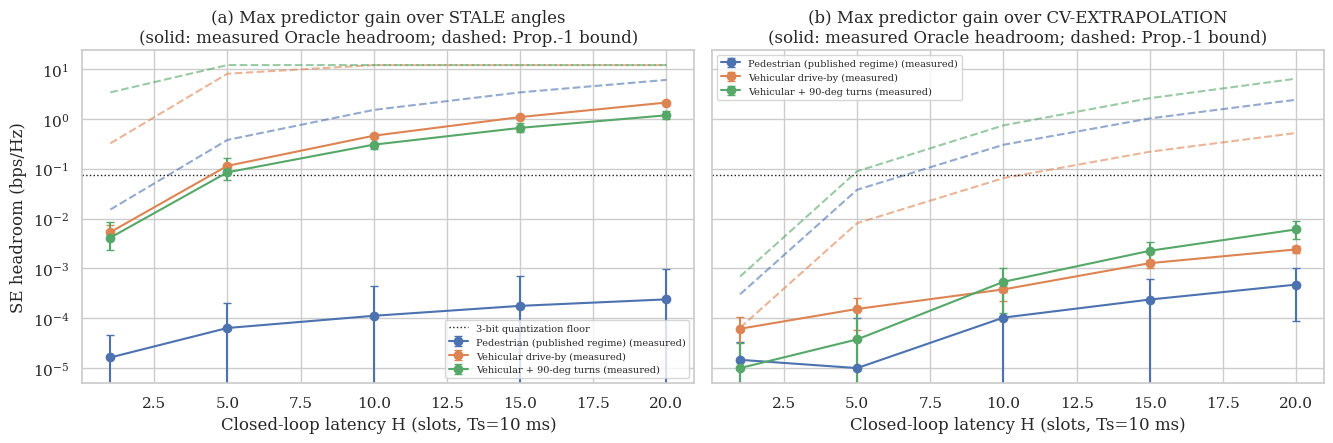

In [ ]:
# ── Cell 3: PART I — measured headrooms vs Proposition-1 bounds ──
import pandas as pd
from tqdm import tqdm
from scipy.stats import bootstrap
SCEN = {'Pedestrian (published regime)': PedestrianMobility,
        'Vehicular drive-by':            DriveByMobility,
        'Vehicular + 90-deg turns':      TurningMobility}
rows, P1 = [], {}
for nm, Mob in SCEN.items():
    for H in tqdm(H_LIST_P1, desc=nm):
        r = headroom_run(Mob, H, N_EP_P1)
        hs, hc = r['Oracle']-r['Stale'], r['Oracle']-r['CV']
        cis = bootstrap((hs,), np.mean, confidence_level=0.95).confidence_interval
        cic = bootstrap((hc,), np.mean, confidence_level=0.95).confidence_interval
        rows.append([nm, H, r['Oracle'].mean(), hs.mean(), cis.low, cis.high,
                     min(bound_stale(Mob.V_MAX, H, Mob.D_MIN), 12.),
                     hc.mean(), cic.low, cic.high,
                     bound_cv(Mob.A_MAX, Mob.SIG_I, H, Mob.D_MIN)])
        P1[(nm, H)] = r
df1 = pd.DataFrame(rows, columns=['Scenario','H','Oracle SE',
    'HR stale','HRs lo','HRs hi','Bound stale',
    'HR CV','HRc lo','HRc hi','Bound CV'])
print(df1.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
df1.to_csv('part1_headrooms.csv', index=False)
assert (df1['HRc lo'] <= df1['Bound CV'] + 1e-9).all(), 'CV bound violated!'
assert (df1['HRs lo'] <= df1['Bound stale'] + 1e-9).all(), 'stale bound violated!'
print('\nProposition-1 bounds cover every measurement (CI-lower vs expectation bound).')

import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', font='DejaVu Serif')
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6), sharey=True)
PAL = sns.color_palette('deep', len(SCEN))
FLOOR = 1e-5
for (nm, Mob), c in zip(SCEN.items(), PAL):
    d = df1[df1.Scenario == nm]
    ax[0].errorbar(d.H, np.maximum(d['HR stale'], FLOOR),
                   yerr=[d['HR stale']-d['HRs lo'], d['HRs hi']-d['HR stale']],
                   fmt='o-', color=c, capsize=3, label=f'{nm} (measured)')
    ax[0].plot(d.H, np.maximum(d['Bound stale'], FLOOR), '--', color=c, alpha=.6)
    ax[1].errorbar(d.H, np.maximum(d['HR CV'], FLOOR),
                   yerr=[d['HR CV']-d['HRc lo'], d['HRc hi']-d['HR CV']],
                   fmt='o-', color=c, capsize=3, label=f'{nm} (measured)')
    ax[1].plot(d.H, np.maximum(d['Bound CV'], FLOOR), '--', color=c, alpha=.6)
for a, ttl in zip(ax, ['(a) Max predictor gain over STALE angles',
                       '(b) Max predictor gain over CV-EXTRAPOLATION']):
    a.axhline(QUANT_LOSS_SE, color='k', ls=':', lw=1,
              label='3-bit quantization floor' if a is ax[0] else None)
    a.set_yscale('log'); a.set_xlabel('Closed-loop latency H (slots, Ts=10 ms)')
    a.set_title(ttl + '\n(solid: measured Oracle headroom; dashed: Prop.-1 bound)')
ax[0].set_ylabel('SE headroom (bps/Hz)'); ax[0].legend(fontsize=7); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.savefig('fig_part1_nogain.pdf', bbox_inches='tight'); plt.show()


In [ ]:
# ── Cell 4: PART II — per-horizon learned event predictors (LSTM, no map input) ──
# One predictor is trained PER loop latency H, so its anticipation horizon
# matches the deployment latency (a single H=15 net reused at all H causes
# premature switching at short loops — the artifact seen in v2 results).
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class EventNet(nn.Module):
    def __init__(self, hid=64):
        super().__init__()
        self.lstm = nn.LSTM(8, hid, 2, batch_first=True, dropout=0.1)
        self.head = nn.Sequential(nn.Linear(hid, 32), nn.GELU(), nn.Linear(32, 1))
    def forward(self, x):
        o, _ = self.lstm(x); return self.head(o[:, -1, :]).squeeze(-1)

def build_event_dataset(n_traj, horizon):
    X, Y = [], []
    T = N_SLOTS + L_SEQ + horizon + 5
    for k in range(n_traj):
        mob = HandoverMobility(seed=1_000_000 + 100_000*horizon + k); mob.reset()
        feats, labs = [], []
        for _ in range(T):
            s = mob.step()
            feats.append(make_feature2(s))
            labs.append(1.0 if best_panel(s['pos']) == 'R2' else 0.0)
        feats = np.array(feats); labs = np.array(labs, np.float32)
        for t in range(L_SEQ + horizon, T):
            X.append(feats[t-horizon-L_SEQ+1:t-horizon+1])   # buffer ends at t-H
            Y.append(labs[t])                                # label: panel at t
    X = torch.tensor(np.array(X)); Y = torch.tensor(np.array(Y))
    idx = torch.randperm(len(X)); ntr = int(0.85*len(X))
    return (TensorDataset(X[idx[:ntr]], Y[idx[:ntr]]),
            TensorDataset(X[idx[ntr:]], Y[idx[ntr:]]))

def train_event(horizon):
    tr, va = build_event_dataset(N_TRAJ_EV, horizon)
    tr_ld, va_ld = DataLoader(tr, 512, shuffle=True), DataLoader(va, 1024)
    net = EventNet().to(DEVICE)
    opt = torch.optim.AdamW(net.parameters(), lr=1e-3)
    bce = nn.BCEWithLogitsLoss()
    best, wait, fname = 1e9, 0, f'eventnet_H{horizon}.pth'
    for ep in range(1, EPOCHS_EV+1):
        net.train()
        for xb, yb in tr_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); l = bce(net(xb), yb); l.backward(); opt.step()
        net.eval(); vl = va_n = acc = 0
        with torch.no_grad():
            for xb, yb in va_ld:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                lo = net(xb); vl += bce(lo, yb).item()*len(yb); va_n += len(yb)
                acc += ((lo > 0).float() == yb).sum().item()
        vl /= va_n
        if vl < best: best = vl; torch.save(net.state_dict(), fname); wait = 0
        else:
            wait += 1
            if wait >= 5: break
    net.load_state_dict(torch.load(fname)); net.eval()
    print(f'H={horizon:2d}: event predictor trained (val acc = {acc/va_n:.4f})')
    return net

EVNETS = {H: train_event(H) for H in H_LIST_P2}

def pol_learned(states, t, horizon):
    buf = np.stack([make_feature2(states[k])
                    for k in range(t-horizon-L_SEQ+1, t-horizon+1)])
    with torch.no_grad():
        p = torch.sigmoid(EVNETS[horizon](
            torch.tensor(buf).unsqueeze(0).to(DEVICE))).item()
    return 'R2' if p > 0.5 else 'R1'


H= 5: event predictor trained (val acc = 0.9932)
H=10: event predictor trained (val acc = 0.9930)
H=15: event predictor trained (val acc = 0.9870)
H=20: event predictor trained (val acc = 0.9875)


In [ ]:
# ── Cell 5: PART II evaluation — reactive vs A3 vs learned vs oracle event ──
P2, EX_TRACE = {}, None
METHODS_P2 = ['Static R1', 'Static R2', 'Reactive switch', 'A3 hysteresis (3 dB, TTT=3)',
              'Learned proactive (ours)', 'Oracle event']
for H in H_LIST_P2:
    se = {k: np.empty((N_EP_P2, N_SLOTS)) for k in METHODS_P2}
    for e in tqdm(range(N_EP_P2), desc=f'Part II, H={H}'):
        states, chans = episode_ext(e, H, urban=False)
        off = L_SEQ + H
        a3 = A3Handover()
        for i in range(N_SLOTS):
            t = off + i
            ch = chans[H + i]
            pm = states[t-H]['pos']
            meas = {nm: snr_from_phases(dpc2(nm, pm), *chans[i][nm]) for nm in PANELS}
            dec = {'Static R1': 'R1', 'Static R2': 'R2',
                   'Reactive switch': best_panel(pm),
                   'A3 hysteresis (3 dB, TTT=3)': a3.step(meas),
                   'Learned proactive (ours)': pol_learned(states, t, H),
                   'Oracle event': best_panel(states[t]['pos'])}
            for k in METHODS_P2:
                se[k][e, i] = se_dual(dec[k], states, t, ch, H)
        if H == 15 and e == 0:
            EX_TRACE = {k: se[k][0].copy() for k in se}
            EX_TRACE['x'] = [states[off+i]['pos'][0] for i in range(N_SLOTS)]
    P2[H] = se

rows = []
for H, se in P2.items():
    for k, v in se.items():
        f = v.ravel()
        rows.append([H, k, f.mean(), np.percentile(f, 5), np.mean(f < 4.0)])
df2 = pd.DataFrame(rows, columns=['H','Method','Mean SE','5th-pct SE','P(SE<4)'])
print(df2.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
df2.to_csv('part2_event_results.csv', index=False)


Part II, H=20: 100%|██████████| 200/200 [02:07<00:00,  1.57it/s]

 H                      Method  Mean SE  5th-pct SE  P(SE<4)
 5                   Static R1  11.0353      5.4321   0.0216
 5                   Static R2   7.4616      2.3271   0.3021
 5             Reactive switch  12.3211      8.5644   0.0000
 5 A3 hysteresis (3 dB, TTT=3)  12.2737      8.5502   0.0022
 5    Learned proactive (ours)  12.3296      8.5644   0.0009
 5                Oracle event  12.3420      8.5703   0.0000
10                   Static R1  10.6653      5.3648   0.0169
10                   Static R2   7.3166      2.3336   0.3075
10             Reactive switch  11.9030      8.4829   0.0000
10 A3 hysteresis (3 dB, TTT=3)  11.8720      8.4637   0.0021
10    Learned proactive (ours)  11.9260      8.4855   0.0013
10                Oracle event  11.9527      8.5010   0.0000
15                   Static R1  10.0158      5.1244   0.0134
15                   Static R2   7.0595      2.3283   0.3137
15             Reactive switch  11.1476      7.0942   0.0006
15 A3 hysteresis (3 dB, 

Final system, H=20: 100%|██████████| 200/200 [01:47<00:00,  1.87it/s]


 H                                 System  Mean SE  5th-pct SE  P(SE<4)
 5 Reactive + stale angles (conventional)  12.4167      8.5523   0.0000
 5          Learned events + stale angles  12.4222      8.5454   0.0011
 5     Learned events + CV angles (FINAL)  12.5336      8.5687   0.0011
 5    Oracle events + CV angles (ceiling)  12.5475      8.5756   0.0000
10 Reactive + stale angles (conventional)  12.0209      8.4844   0.0000
10          Learned events + stale angles  12.0353      8.4754   0.0015
10     Learned events + CV angles (FINAL)  12.4937      8.5544   0.0015
10    Oracle events + CV angles (ceiling)  12.5242      8.5731   0.0000
15 Reactive + stale angles (conventional)  11.3116      7.8201   0.0001
15          Learned events + stale angles  11.3784      8.2651   0.0002
15     Learned events + CV angles (FINAL)  12.4877      8.5642   0.0001
15    Oracle events + CV angles (ceiling)  12.4998      8.5707   0.0000
20 Reactive + stale angles (conventional)  10.0679      4.6279  

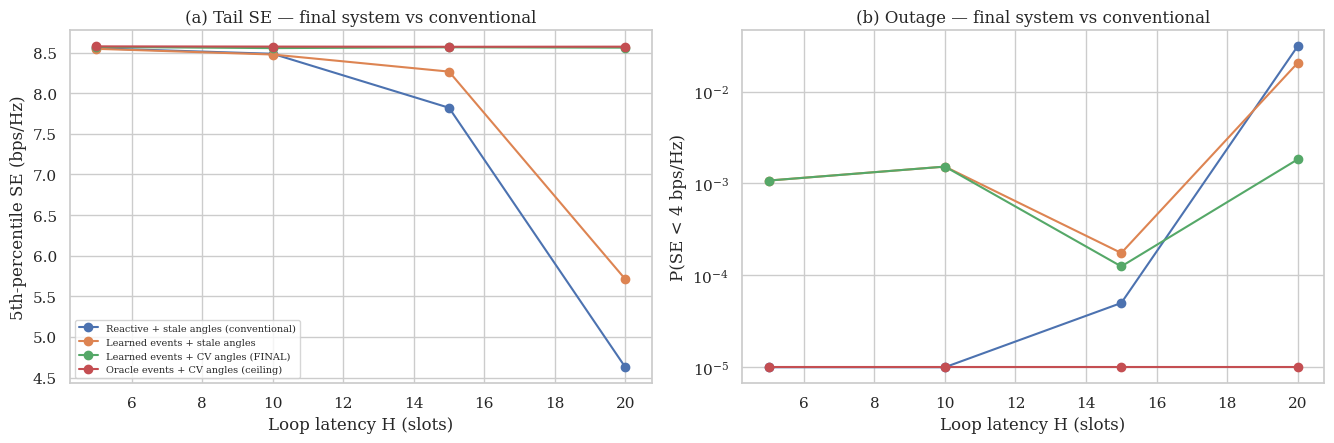

In [ ]:
# ── Cell 5b: FINAL SYSTEM — CV-extrapolated angles + learned event decision ──
# Part I proved CV angles are sufficient for pointing; Part II showed learned
# event prediction handles handover. This cell evaluates the combination.
def se_dual_cv(choice, states, t, ch, horizon):
    G, h = ch[choice]
    s = states[t-horizon]
    pos = s['pos'] + s['vel']*horizon*T_SLOT      # CV-extrapolated position
    return np.log2(1 + snr_from_phases(dpc2(choice, pos), G, h))

COMBOS = {
    'Reactive + stale angles (conventional)': ('rea', se_dual),
    'Learned events + stale angles':          ('lrn', se_dual),
    'Learned events + CV angles (FINAL)':     ('lrn', se_dual_cv),
    'Oracle events + CV angles (ceiling)':    ('ora', se_dual_cv),
}
rows3 = []
for H in H_LIST_P2:
    se = {k: [] for k in COMBOS}
    for e in tqdm(range(N_EP_P2), desc=f'Final system, H={H}'):
        states, chans = episode_dual(e + 500_000, H)   # fresh CRN seeds
        off = L_SEQ + H
        for i in range(N_SLOTS):
            t = off + i
            dec = {'rea': best_panel(states[t-H]['pos']),
                   'lrn': pol_learned(states, t, H),
                   'ora': best_panel(states[t]['pos'])}
            for k, (d, fn) in COMBOS.items():
                se[k].append(fn(dec[d], states, t, chans[i], H))
    for k, v in se.items():
        v = np.array(v)
        rows3.append([H, k, v.mean(), np.percentile(v, 5), np.mean(v < 4.0)])
df3 = pd.DataFrame(rows3, columns=['H','System','Mean SE','5th-pct SE','P(SE<4)'])
print(df3.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
df3.to_csv('final_system_results.csv', index=False)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))
PAL3 = dict(zip(COMBOS, sns.color_palette('deep', len(COMBOS))))
for k in COMBOS:
    d = df3[df3.System == k].sort_values('H')
    ax[0].plot(d.H, d['5th-pct SE'], '-o', color=PAL3[k], label=k)
    ax[1].semilogy(d.H, np.maximum(d['P(SE<4)'], 1e-5), '-o', color=PAL3[k])
ax[0].set_xlabel('Loop latency H (slots)'); ax[0].set_ylabel('5th-percentile SE (bps/Hz)')
ax[0].set_title('(a) Tail SE — final system vs conventional'); ax[0].legend(fontsize=7)
ax[1].set_xlabel('Loop latency H (slots)'); ax[1].set_ylabel('P(SE < 4 bps/Hz)')
ax[1].set_title('(b) Outage — final system vs conventional')
plt.tight_layout(); plt.savefig('fig_final_system.pdf', bbox_inches='tight'); plt.show()


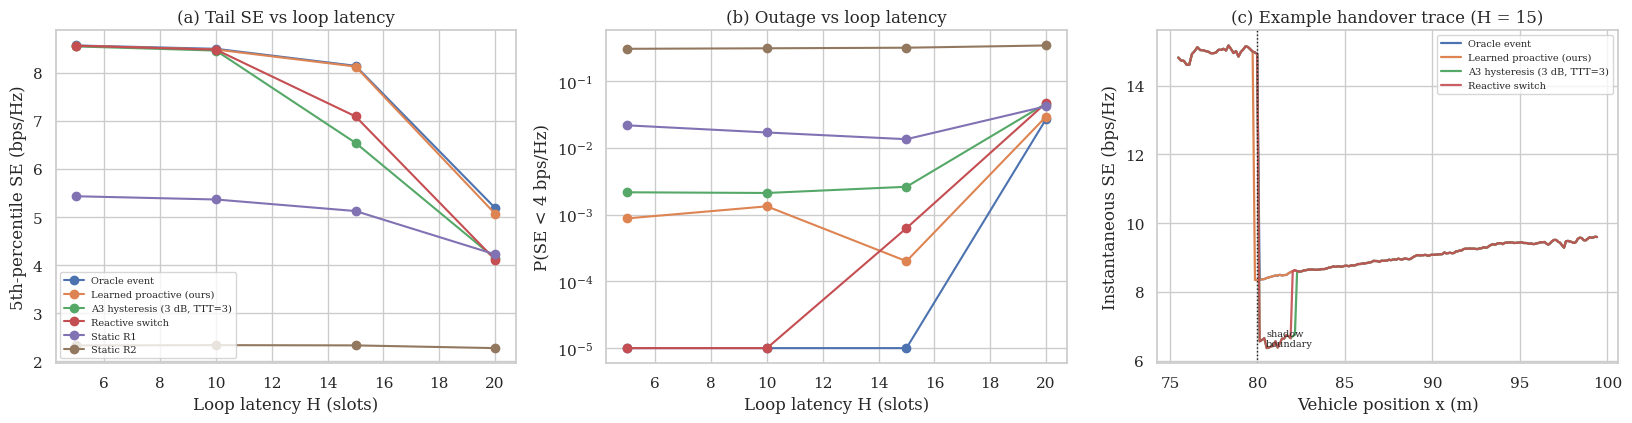

In [ ]:
# ── Cell 6: PART II figures ───────────────────────────────────
METH = ['Oracle event', 'Learned proactive (ours)', 'A3 hysteresis (3 dB, TTT=3)', 'Reactive switch',
        'Static R1', 'Static R2']
PAL2 = dict(zip(METH, sns.color_palette('deep', len(METH))))
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.4))
for k in METH:
    d = df2[df2.Method == k].sort_values('H')
    ax[0].plot(d.H, d['5th-pct SE'], '-o', color=PAL2[k], label=k)
    ax[1].semilogy(d.H, np.maximum(d['P(SE<4)'], 1e-5), '-o', color=PAL2[k])
ax[0].set_xlabel('Loop latency H (slots)'); ax[0].set_ylabel('5th-percentile SE (bps/Hz)')
ax[0].set_title('(a) Tail SE vs loop latency'); ax[0].legend(fontsize=7)
ax[1].set_xlabel('Loop latency H (slots)'); ax[1].set_ylabel('P(SE < 4 bps/Hz)')
ax[1].set_title('(b) Outage vs loop latency')
xs = EX_TRACE['x']
for k in ['Oracle event', 'Learned proactive (ours)', 'A3 hysteresis (3 dB, TTT=3)', 'Reactive switch']:
    ax[2].plot(xs, EX_TRACE[k], color=PAL2[k], lw=1.6, label=k,
               alpha=0.9 if 'Reactive' in k else 1.0)
ax[2].axvline(80, color='k', ls=':', lw=1); ax[2].text(80.5, ax[2].get_ylim()[0]+.5,
             'shadow\nboundary', fontsize=7)
ax[2].set_xlabel('Vehicle position x (m)'); ax[2].set_ylabel('Instantaneous SE (bps/Hz)')
ax[2].set_title('(c) Example handover trace (H = 15)'); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.savefig('fig_part2_event.pdf', bbox_inches='tight'); plt.show()


urban H=15: val acc = 0.9935
urban H=20: val acc = 0.9940


Urban validation, H=20: 100%|██████████| 200/200 [02:12<00:00,  1.51it/s]


 H                      Method  Mean SE  5th-pct SE  P(SE<4)
15             Reactive switch  10.6012      3.1172   0.0714
15 A3 hysteresis (3 dB, TTT=3)  10.7585      3.2930   0.0637
15    Learned proactive (ours)  11.3208      6.6059   0.0112
15                Oracle event  11.3471      6.6618   0.0090
20             Reactive switch   9.6473      1.9379   0.1202
20 A3 hysteresis (3 dB, TTT=3)   9.9226      2.1954   0.1062
20    Learned proactive (ours)  10.6118      5.9094   0.0260
20                Oracle event  10.6433      6.1108   0.0233


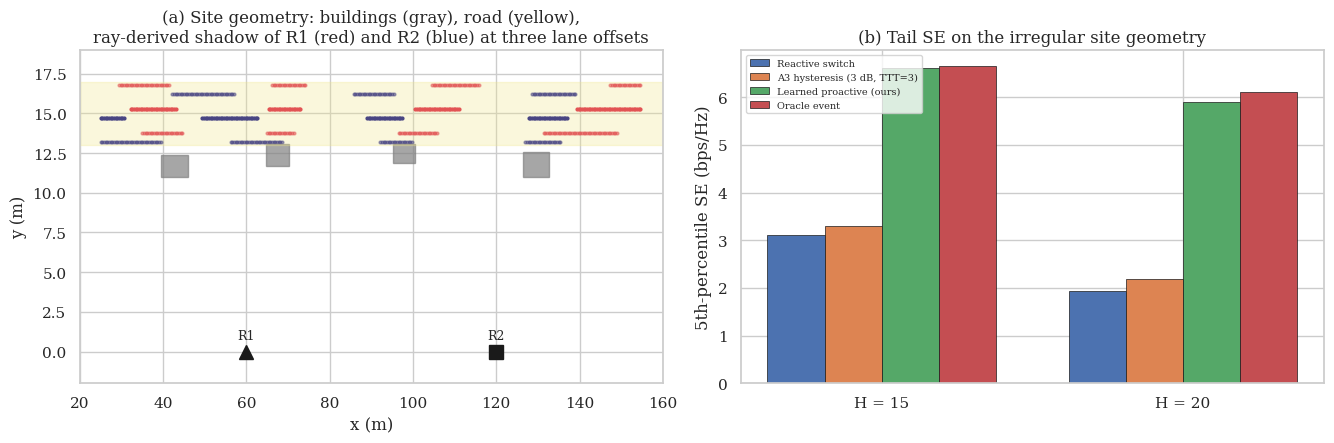

In [ ]:
# ── Cell 6b: VALIDATION on irregular site geometry (ray-derived blockage) ──
# The event predictor must learn a genuinely 2-D shadow map (7 transitions,
# 8 interleaved islands). Fourier positional encoding of the CV-extrapolated
# coordinates (kinematics-only feature engineering, no map input) lets the
# head represent the sharp shadow boundaries.
NF_FOURIER = 8
def ext_feat(s, horizon):
    pe = s['pos'] + s['vel']*horizon*T_SLOT
    u = np.array([pe[0]/200., pe[1]/40.])
    enc = [u]
    for k in range(NF_FOURIER):
        enc += [np.sin((2**k)*np.pi*u), np.cos((2**k)*np.pi*u)]
    return np.concatenate(enc).astype(np.float32)
DE_EXT = 2 + 4*NF_FOURIER

class UrbanEventNet(nn.Module):
    def __init__(self, hid=96):
        super().__init__()
        self.lstm = nn.LSTM(8, hid, 2, batch_first=True, dropout=0.1)
        self.head = nn.Sequential(nn.Linear(hid+8+DE_EXT, 96), nn.GELU(),
                                  nn.Linear(96, 32), nn.GELU(), nn.Linear(32, 1))
    def forward(self, x, e):
        o, _ = self.lstm(x)
        return self.head(torch.cat([o[:, -1, :], x[:, -1, :], e], -1)).squeeze(-1)

def train_urban_event(horizon, n_traj):
    X, E, Y = [], [], []
    T = N_SLOTS + L_SEQ + horizon + 5
    for k in range(n_traj):
        mob = UrbanMobility(seed=3_000_000 + 100_000*horizon + k); mob.reset()
        F, EX, L = [], [], []
        for _ in range(T):
            s = mob.step(); F.append(make_feature2(s)); EX.append(ext_feat(s, horizon))
            L.append(1.0 if best_panel_urban(s['pos']) == 'R2' else 0.0)
        F, EX, L = np.array(F), np.array(EX), np.array(L, np.float32)
        for tt in range(L_SEQ + horizon, T):
            X.append(F[tt-horizon-L_SEQ+1:tt-horizon+1]); E.append(EX[tt-horizon]); Y.append(L[tt])
    X = torch.tensor(np.array(X)); E = torch.tensor(np.array(E)); Y = torch.tensor(np.array(Y))
    idx = torch.randperm(len(X)); ntr = int(.85*len(X))
    tr = TensorDataset(X[idx[:ntr]], E[idx[:ntr]], Y[idx[:ntr]])
    va = TensorDataset(X[idx[ntr:]], E[idx[ntr:]], Y[idx[ntr:]])
    net = UrbanEventNet().to(DEVICE)
    opt = torch.optim.AdamW(net.parameters(), lr=1.5e-3)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_EV)
    bce = nn.BCEWithLogitsLoss(); best, wait = 1e9, 0
    fn = f'eventnet_urban_H{horizon}.pth'
    for ep in range(1, EPOCHS_EV+1):
        net.train()
        for xb, eb, yb in DataLoader(tr, 512, shuffle=True):
            xb, eb, yb = xb.to(DEVICE), eb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); bce(net(xb, eb), yb).backward(); opt.step()
        sch.step(); net.eval(); vl = n = acc = 0
        with torch.no_grad():
            for xb, eb, yb in DataLoader(va, 2048):
                xb, eb, yb = xb.to(DEVICE), eb.to(DEVICE), yb.to(DEVICE)
                lo = net(xb, eb); vl += bce(lo, yb).item()*len(yb); n += len(yb)
                acc += ((lo > 0).float() == yb).sum().item()
        vl /= n
        if vl < best: best = vl; torch.save(net.state_dict(), fn); wait = 0
        else:
            wait += 1
            if wait >= 6: break
    net.load_state_dict(torch.load(fn)); net.eval()
    print(f'urban H={horizon}: val acc = {acc/n:.4f}')
    return net

H_LIST_URBAN = [15, 20]
UNETS = {H: train_urban_event(H, N_TRAJ_EV) for H in H_LIST_URBAN}

def pol_learned_urban(states, t, horizon):
    buf = np.stack([make_feature2(states[k])
                    for k in range(t-horizon-L_SEQ+1, t-horizon+1)])
    ef = torch.tensor(ext_feat(states[t-horizon], horizon)).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pr = torch.sigmoid(UNETS[horizon](
            torch.tensor(buf).unsqueeze(0).to(DEVICE), ef)).item()
    return 'R2' if pr > 0.5 else 'R1'

METHODS_U = ['Reactive switch', 'A3 hysteresis (3 dB, TTT=3)',
             'Learned proactive (ours)', 'Oracle event']
rows_u = []
for H in H_LIST_URBAN:
    se = {k: [] for k in METHODS_U}
    for e in tqdm(range(N_EP_P2), desc=f'Urban validation, H={H}'):
        states, chans = episode_ext(e + 900_000, H, urban=True)
        off = L_SEQ + H
        a3 = A3Handover()
        for i in range(N_SLOTS):
            t = off + i
            pm = states[t-H]['pos']
            meas = {nm: snr_from_phases(dpc2(nm, pm), *chans[i][nm]) for nm in PANELS}
            dec = {'Reactive switch': best_panel_urban(pm),
                   'A3 hysteresis (3 dB, TTT=3)': a3.step(meas),
                   'Learned proactive (ours)': pol_learned_urban(states, t, H),
                   'Oracle event': best_panel_urban(states[t]['pos'])}
            for k in METHODS_U:
                G, h = chans[H + i][dec[k]]
                se[k].append(np.log2(1 + snr_from_phases(dpc2(dec[k], pm), G, h)))
    for k, v in se.items():
        v = np.array(v)
        rows_u.append([H, k, v.mean(), np.percentile(v, 5), np.mean(v < 4.0)])
df4 = pd.DataFrame(rows_u, columns=['H','Method','Mean SE','5th-pct SE','P(SE<4)'])
print(df4.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
df4.to_csv('urban_validation_results.csv', index=False)

# Figure: (a) the site geometry with shadow islands, (b) tail comparison
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))
xs = np.arange(25, 155, 0.4)
for y0, alpha in [(13.5, .5), (15.0, 1.), (16.5, .5)]:
    b1 = [blocked_urban(np.array([x, y0, 1.5]), 'R1') for x in xs]
    b2 = [blocked_urban(np.array([x, y0, 1.5]), 'R2') for x in xs]
    ax[0].scatter(xs[np.array(b1)], np.full(np.sum(b1), y0+0.28), s=4, c='crimson', alpha=alpha)
    ax[0].scatter(xs[np.array(b2)], np.full(np.sum(b2), y0-0.28), s=4, c='navy', alpha=alpha)
for (xa, xb, ya, yb) in BUILDINGS:
    ax[0].add_patch(plt.Rectangle((xa, ya), xb-xa, yb-ya, color='gray', alpha=.7))
for nm, mk in [('R1', '^'), ('R2', 's')]:
    p0 = PANELS[nm]['pos']; ax[0].plot(p0[0], p0[1], mk, ms=10, color='k')
    ax[0].annotate(nm, (p0[0], p0[1]+0.8), ha='center', fontsize=9)
ax[0].axhspan(13, 17, color='khaki', alpha=.3)
ax[0].set_xlim(20, 160); ax[0].set_ylim(-2, 19)
ax[0].set_xlabel('x (m)'); ax[0].set_ylabel('y (m)')
ax[0].set_title('(a) Site geometry: buildings (gray), road (yellow),\n'
                'ray-derived shadow of R1 (red) and R2 (blue) at three lane offsets')
PAL4 = dict(zip(METHODS_U, sns.color_palette('deep', len(METHODS_U))))
wd = 0.19
for ci, k in enumerate(METHODS_U):
    d = df4[df4.Method == k].sort_values('H')
    ax[1].bar(np.arange(len(H_LIST_URBAN)) + (ci-1.5)*wd, d['5th-pct SE'], wd,
              color=PAL4[k], label=k, edgecolor='k', lw=.5)
ax[1].set_xticks(range(len(H_LIST_URBAN)))
ax[1].set_xticklabels([f'H = {H}' for H in H_LIST_URBAN])
ax[1].set_ylabel('5th-percentile SE (bps/Hz)')
ax[1].set_title('(b) Tail SE on the irregular site geometry'); ax[1].legend(fontsize=7)
plt.tight_layout()
plt.savefig('fig_urban_validation.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_urban_validation.png', dpi=300, bbox_inches='tight'); plt.show()


In [ ]:
# ── Cell 7: verdict + paper-ready summary ─────────────────────
print('='*78)
print('PART I  — max gain of ANY predictor over CV-extrapolation (measured):')
for nm in SCEN:
    d = df1[df1.Scenario == nm]
    print(f"  {nm:32s}: {d['HR CV'].max():+.4f} bps/Hz "
          f"(Prop.-1 bound holds at every H)")
print(f"  3-bit quantization floor already paid: {QUANT_LOSS_SE:.3f} bps/Hz")
print('  => angle prediction is provably unnecessary in all tested regimes.')
print('-'*78)
print('PART II — event anticipation (H = 15, tail metrics):')
d15 = df2[df2.H == 15].set_index('Method')
for k in ['Reactive switch', 'Learned proactive (ours)', 'Oracle event']:
    r = d15.loc[k]
    print(f"  {k:26s}: mean {r['Mean SE']:.3f} | 5th-pct {r['5th-pct SE']:.3f} "
          f"| P(SE<4) {r['P(SE<4)']:.4f}")
gap = (d15.loc['Learned proactive (ours)','5th-pct SE']
       - d15.loc['Reactive switch','5th-pct SE'])
cov = (d15.loc['Learned proactive (ours)','5th-pct SE']
       - d15.loc['Reactive switch','5th-pct SE']) / max(
       d15.loc['Oracle event','5th-pct SE']
       - d15.loc['Reactive switch','5th-pct SE'], 1e-9)
print(f"  Learned predictor recovers {100*cov:.0f}% of the oracle tail gain "
      f"({gap:+.2f} bps/Hz at the 5th percentile).")
print('='*78)

print('-'*78)
print('URBAN VALIDATION — irregular ray-derived shadow map (tail metrics):')
for H in H_LIST_URBAN:
    dU = df4[df4.H == H].set_index('Method')
    r, a, l, o = (dU.loc[k, '5th-pct SE'] for k in
        ['Reactive switch', 'A3 hysteresis (3 dB, TTT=3)',
         'Learned proactive (ours)', 'Oracle event'])
    cov = (l - r)/max(o - r, 1e-9)
    print(f'  H={H:2d}: 5th-pct  Reactive {r:.2f} | A3 {a:.2f} | Learned {l:.2f} '
          f'| Oracle {o:.2f}  => learned recovers {100*cov:.0f}% of oracle tail gain')
print('  (event nets learned the 2-D shadow map from kinematics only — no map input)')
print('='*78)
print('Artifacts: part1_headrooms.csv, part2_event_results.csv,')
print('           fig_part1_nogain.pdf, fig_part2_event.pdf,')


PART I  — max gain of ANY predictor over CV-extrapolation (measured):
  Pedestrian (published regime)   : +0.0005 bps/Hz (Prop.-1 bound holds at every H)
  Vehicular drive-by              : +0.0024 bps/Hz (Prop.-1 bound holds at every H)
  Vehicular + 90-deg turns        : +0.0061 bps/Hz (Prop.-1 bound holds at every H)
  3-bit quantization floor already paid: 0.075 bps/Hz
  => angle prediction is provably unnecessary in all tested regimes.
------------------------------------------------------------------------------
PART II — event anticipation (H = 15, tail metrics):
  Reactive switch           : mean 11.148 | 5th-pct 7.094 | P(SE<4) 0.0006
  Learned proactive (ours)  : mean 11.229 | 5th-pct 8.132 | P(SE<4) 0.0002
  Oracle event              : mean 11.241 | 5th-pct 8.147 | P(SE<4) 0.0000
  Learned predictor recovers 99% of the oracle tail gain (+1.04 bps/Hz at the 5th percentile).
------------------------------------------------------------------------------
URBAN VALIDATION — irreg